In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip "/content/drive/MyDrive/Remote Sensing/RS_2026_1학기/Egypt_Siwa_saltlake.zip" -d /content/

Archive:  /content/drive/MyDrive/Remote Sensing/RS_2026_1학기/Egypt_Siwa_saltlake.zip
   creating: /content/predictions/
  inflating: /content/predictions/Egypt_Siwa_saltlake_10768_201610.cpg  
  inflating: /content/predictions/Egypt_Siwa_saltlake_10768_201610.dbf  
  inflating: /content/predictions/Egypt_Siwa_saltlake_10768_201610.prj  
  inflating: /content/predictions/Egypt_Siwa_saltlake_10768_201610.shp  
  inflating: /content/predictions/Egypt_Siwa_saltlake_10768_201610.shx  
  inflating: /content/predictions/Egypt_Siwa_saltlake_11351_201901.cpg  
  inflating: /content/predictions/Egypt_Siwa_saltlake_11351_201901.dbf  
  inflating: /content/predictions/Egypt_Siwa_saltlake_11351_201901.prj  
  inflating: /content/predictions/Egypt_Siwa_saltlake_11351_201901.shp  
  inflating: /content/predictions/Egypt_Siwa_saltlake_11351_201901.shx  
  inflating: /content/predictions/Egypt_Siwa_saltlake_12457_202304.cpg  
  inflating: /content/predictions/Egypt_Siwa_saltlake_12457_202304.dbf  
  inf

In [ ]:
import subprocess
import csv
import os
import glob
import numpy as np
import random
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF

# Segmentation Models Pytorch 설치 및 임포트
try:
    import segmentation_models_pytorch as smp
except ImportError:
    subprocess.run(["pip", "install", "-q", "segmentation-models-pytorch"], check=True)
    import segmentation_models_pytorch as smp

# ──────────────────────────────────────────────
# 설정
# ──────────────────────────────────────────────
BASE_DIR   = "/content/Egypt_Siwa_saltlake/"
IMAGE_DIR  = os.path.join(BASE_DIR, "image")
LABEL_DIR  = os.path.join(BASE_DIR, "label")
DATA_DIR   = os.path.join(BASE_DIR, "data")
PRED_DIR   = os.path.join(BASE_DIR, "predictions")
MODEL_PATH = os.path.join(BASE_DIR, "deeplab_saltlake_best.pth")

BATCH_SIZE = 8
EPOCHS     = 60
LR         = 1e-4
ENCODER_LR = 1e-5   # pretrained encoder는 낮은 LR로 fine-tune
VAL_RATIO  = 0.15
THRESHOLD  = 0.45   # salt lake을 놓치지 않도록 약간 낮게 설정
DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"

os.makedirs(PRED_DIR, exist_ok=True)
print(f"Device: {DEVICE}")


Device: cuda


In [ ]:

# ──────────────────────────────────────────────
# Dataset
# ──────────────────────────────────────────────
class SaltLakeDataset(Dataset):
    def __init__(self, image_paths, label_paths, augment=False):
        self.image_paths = image_paths
        self.label_paths = label_paths
        self.augment = augment

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB")
        lbl = Image.open(self.label_paths[idx])

        if self.augment:
            # 수평/수직 뒤집기
            if random.random() > 0.5:
                img = TF.hflip(img); lbl = TF.hflip(lbl)
            if random.random() > 0.5:
                img = TF.vflip(img); lbl = TF.vflip(lbl)

            # 90도 단위 회전
            angle = random.choice([0, 90, 180, 270])
            if angle != 0:
                img = TF.rotate(img, angle)
                lbl = TF.rotate(lbl, angle)

            # 밝기/대비 조정
            if random.random() > 0.5:
                img = TF.adjust_brightness(img, random.uniform(0.8, 1.2))
            if random.random() > 0.5:
                img = TF.adjust_contrast(img, random.uniform(0.8, 1.2))

        img = TF.to_tensor(img)
        img = TF.normalize(img, [0.485, 0.456, 0.406], [0.229, 0.224, 0.225])

        # 레이블 이진화 (1이 salt lake)
        lbl_np = np.array(lbl)
        lbl_tensor = torch.from_numpy((lbl_np > 0).astype(np.float32)).unsqueeze(0)

        return img, lbl_tensor


class PredictDataset(Dataset):
    def __init__(self, image_paths):
        self.image_paths = image_paths

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB")
        img = TF.to_tensor(img)
        img = TF.normalize(img, [0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        return img, os.path.basename(self.image_paths[idx])


# ──────────────────────────────────────────────
# Loss: Focal + Dice
# ──────────────────────────────────────────────
class FocalDiceLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2.0, focal_weight=0.5):
        """
        alpha        : 양성 클래스 가중치. 0.75 → salt lake에 더 큰 페널티.
        gamma        : focusing parameter. 잘 분류된 easy example의 loss를 억제.
        focal_weight : focal_loss : dice_loss 비율.
        """
        super().__init__()
        self.alpha        = alpha
        self.gamma        = gamma
        self.focal_weight = focal_weight

    def forward(self, logits, targets):
        # Focal Loss
        bce     = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        probs   = torch.sigmoid(logits)
        p_t     = probs * targets + (1 - probs) * (1 - targets)
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        focal_loss = (alpha_t * (1 - p_t) ** self.gamma * bce).mean()

        # Dice Loss
        smooth    = 1e-6
        inter     = (probs * targets).sum(dim=(1, 2, 3))
        union     = probs.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3))
        dice_loss = 1 - (2 * inter + smooth) / (union + smooth)

        return self.focal_weight * focal_loss + (1 - self.focal_weight) * dice_loss.mean()


# ──────────────────────────────────────────────
# 모델 생성
# ──────────────────────────────────────────────
def build_model():
    return smp.DeepLabV3Plus(
        encoder_name    = "resnet50",
        encoder_weights = "imagenet",
        in_channels     = 3,
        classes         = 1,
        activation      = None,
    ).to(DEVICE)


# ──────────────────────────────────────────────
# 학습
# ──────────────────────────────────────────────
def train():
    # 1. 데이터 수집 및 균형 조정 (salt lake 있는 이미지 / 없는 이미지 분리)
    all_image_paths = sorted(glob.glob(os.path.join(IMAGE_DIR, "*.png")))
    pos_pairs = []
    neg_pairs = []

    print("데이터 필터링 중...")
    for img_p in tqdm(all_image_paths):
        lbl_p = os.path.join(LABEL_DIR, os.path.splitext(os.path.basename(img_p))[0] + ".tif")
        if os.path.exists(lbl_p):
            lbl_arr = np.array(Image.open(lbl_p))
            if np.sum(lbl_arr) > 0:
                pos_pairs.append((img_p, lbl_p))
            else:
                neg_pairs.append((img_p, lbl_p))

    if not pos_pairs:
        raise FileNotFoundError(f"Salt lake 레이블이 있는 이미지를 찾을 수 없습니다.\nIMAGE_DIR: {IMAGE_DIR}")

    # salt lake 있는 데이터 + 배경 데이터 (salt lake 이미지보다 약간만 더 많게)
    random.seed(42)
    random.shuffle(neg_pairs)
    balanced_pairs = pos_pairs + neg_pairs[:len(pos_pairs) + 20]
    random.shuffle(balanced_pairs)

    img_paths, lbl_paths = map(list, zip(*balanced_pairs))
    print(f"학습 데이터: 총 {len(img_paths)}개 (salt lake 포함: {len(pos_pairs)}개, 배경: {len(neg_pairs[:len(pos_pairs)+20])}개)")

    # 2. Train / Val 분할
    n_val = max(1, int(len(img_paths) * VAL_RATIO))
    train_ds = SaltLakeDataset(img_paths[n_val:], lbl_paths[n_val:], augment=True)
    val_ds   = SaltLakeDataset(img_paths[:n_val], lbl_paths[:n_val], augment=False)
    print(f"Train: {len(train_ds)}개 / Val: {len(val_ds)}개")

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, drop_last=True)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    model     = build_model()
    criterion = FocalDiceLoss(alpha=0.75, gamma=2.0, focal_weight=0.5)

    # encoder(pretrained)는 낮은 LR, decoder/head는 높은 LR
    optimizer = optim.Adam([
        {"params": model.encoder.parameters(),           "lr": ENCODER_LR},
        {"params": model.decoder.parameters(),           "lr": LR},
        {"params": model.segmentation_head.parameters(), "lr": LR},
    ])
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, "min", patience=5, factor=0.5)


    # -------------------------------------------------------
    # [로그 저장 준비] CSV 파일 초기화 및 헤더 작성
    # -------------------------------------------------------
    LOG_CSV_PATH = "training_log.csv"
    with open(LOG_CSV_PATH, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(['epoch', 'train_loss', 'val_loss', 'val_iou'])
    print(f"Encoder LR: {ENCODER_LR}  |  Decoder/Head LR: {LR}")

    best_iou = 0.0

    for epoch in range(1, EPOCHS + 1):
        # Train
        model.train()
        train_loss = 0.0
        for imgs, lbls in tqdm(train_loader, desc=f"Epoch {epoch:02d}/{EPOCHS} [train]", leave=False):
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(imgs), lbls)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * imgs.size(0)
        train_loss /= len(train_ds)

        # Validation
        model.eval()
        val_loss = 0.0
        val_iou  = 0.0
        with torch.no_grad():
            for imgs, lbls in val_loader:
                imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
                preds    = model(imgs)
                val_loss += criterion(preds, lbls).item() * imgs.size(0)

                pred_bin = (torch.sigmoid(preds) > THRESHOLD).float()
                inter    = (pred_bin * lbls).sum(dim=(2, 3))
                union    = (pred_bin + lbls).clamp(0, 1).sum(dim=(2, 3))
                val_iou  += ((inter + 1e-7) / (union + 1e-7)).mean().item() * imgs.size(0)

        val_loss /= len(val_ds)
        val_iou  /= len(val_ds)
        scheduler.step(train_loss)

        # -------------------------------------------------------
        # [로그 저장] 매 에포크 결과를 CSV 파일에 추가(Append)
        # -------------------------------------------------------
        with open(LOG_CSV_PATH, 'a', newline='') as f:
            writer = csv.writer(f)
            writer.writerow([epoch, train_loss, val_loss, val_iou])
        print(f"Epoch {epoch:02d}/{EPOCHS}  train_loss={train_loss:.4f}  val_loss={val_loss:.4f}  val_IoU={val_iou:.4f}")

        # Best 모델은 IoU 기준으로 저장
        if val_iou > best_iou:
            best_iou = val_iou
            torch.save(model.state_dict(), MODEL_PATH)
            print(f"  ★ Best IoU Saved: {best_iou:.4f}")

    print(f"\n학습 완료. 최적 모델: {MODEL_PATH}")
    print(f"학습 로그가 {LOG_CSV_PATH}에 저장되었습니다.")

# ──────────────────────────────────────────────
# 예측 - data/ 하위 시점 폴더별로 처리
# ──────────────────────────────────────────────
def predict():
    model = build_model()
    if not os.path.exists(MODEL_PATH):
        print("학습된 모델 파일이 없습니다.")
        return
    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
    model.eval()

    # data/ 안의 하위 폴더(시점) 목록
    time_folders = sorted([
        d for d in os.listdir(DATA_DIR)
        if os.path.isdir(os.path.join(DATA_DIR, d))
    ])
    if not time_folders:
        raise FileNotFoundError(f"data/ 하위 폴더가 없습니다: {DATA_DIR}")

    print(f"예측 시점 폴더: {time_folders}")

    with torch.no_grad():
        for folder in time_folders:
            src_dir    = os.path.join(DATA_DIR, folder)
            out_dir    = os.path.join(PRED_DIR, folder)
            os.makedirs(out_dir, exist_ok=True)

            data_paths  = sorted(glob.glob(os.path.join(src_dir, "*.png")))
            print(f"\n[{folder}] {len(data_paths)}개 이미지 예측 중...")

            pred_ds     = PredictDataset(data_paths)
            pred_loader = DataLoader(pred_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

            for imgs, fnames in tqdm(pred_loader, desc=folder, leave=False):
                imgs  = imgs.to(DEVICE)
                masks = (torch.sigmoid(model(imgs)) > THRESHOLD).squeeze(1).cpu().numpy().astype(np.uint8) * 255
                for mask, fname in zip(masks, fnames):
                    out_path = os.path.join(out_dir, os.path.splitext(fname)[0] + ".png")
                    Image.fromarray(mask).save(out_path)

            print(f"  → 저장 완료: {out_dir}")

    print(f"\n전체 예측 완료. 결과 위치: {PRED_DIR}")


# ──────────────────────────────────────────────
if __name__ == "__main__":
    print("=" * 50)
    print("1단계: 모델 학습 (DeepLabV3+ / Egypt_Siwa_saltlake)")
    print("=" * 50)
    train()

    print("\n" + "=" * 50)
    print("2단계: 예측 (data/ 하위 시점 폴더별)")
    print("=" * 50)
    predict()


1단계: 모델 학습 (DeepLabV3+ / Egypt_Siwa_saltlake)
데이터 필터링 중...


100%|██████████| 430/430 [00:00<00:00, 726.55it/s]


학습 데이터: 총 430개 (salt lake 포함: 208개, 배경: 222개)
Train: 366개 / Val: 64개


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

...

Epoch 58/60  train_loss=0.2817  val_loss=0.3074  val_IoU=0.6832


Epoch 59/60  train_loss=0.2820  val_loss=0.3020  val_IoU=0.7504


Epoch 60/60  train_loss=0.2851  val_loss=0.3005  val_IoU=0.7962
  ★ Best IoU Saved: 0.7962

학습 완료. 최적 모델: /content/Egypt_Siwa_saltlake/deeplab_saltlake_best.pth
학습 로그가 training_log.csv에 저장되었습니다.

2단계: 예측 (data/ 하위 시점 폴더별)
예측 시점 폴더: ['9181_201911', '__pycache__']

[9181_201911] 5개 이미지 예측 중...


  → 저장 완료: /content/Egypt_Siwa_saltlake/predictions/9181_201911

[__pycache__] 0개 이미지 예측 중...


  → 저장 완료: /content/Egypt_Siwa_saltlake/predictions/__pycache__

전체 예측 완료. 결과 위치: /content/Egypt_Siwa_saltlake/predictions


In [ ]:
import shutil
import os

# 압축할 폴더 경로
source_dir = "/content/Egypt_Siwa_saltlake/predictions"
# 저장될 압축 파일 이름 (확장자 제외)
output_filename = "/content/Siwa_predictions"

if os.path.exists(source_dir):
    shutil.make_archive(output_filename, 'zip', source_dir)
    print(f"압축 완료: {output_filename}.zip")
else:
    print("폴더 경로를 찾을 수 없습니다. 경로를 다시 확인해주세요.")

압축 완료: /content/Siwa_predictions.zip


In [ ]:
from google.colab import files

files.download('/content/Siwa_predictions.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

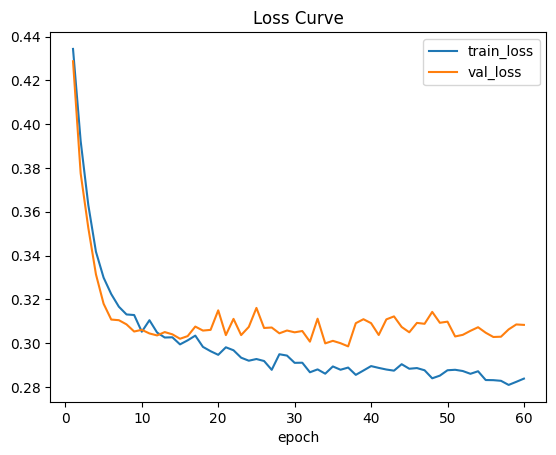

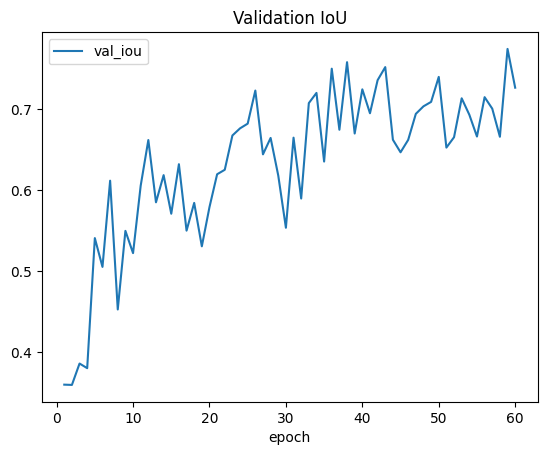

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("training_log.csv")
df.plot(x='epoch', y=['train_loss', 'val_loss'], title='Loss Curve')
df.plot(x='epoch', y='val_iou', title='Validation IoU')
plt.show()